# Задание по продуктовой аналитике. Zahoruiko Anna

In [1]:
import pandas as pd
import numpy as np
import pickle

In [2]:
with open("data.pickle", "rb") as f:
    df_calls, df_contacts, df_deals, df_spend = pickle.load(f)

print("Датафреймы успешно загружены")

Датафреймы успешно загружены


## ПРОДУКТОВАЯ АНАЛИТИКА 

**Найти точку роста бизнеса и сформулировать гипотезу улучшение бизнес процесса для роста метрик и опишите их механику тестирования с учетом того что тест не должен занимать больше 2-х недель.**

#### 1. Посчитать юнит-экономику по продуктам.

In [19]:
df = df_deals.copy()

df["is_paid"] = df["Payment_Status"].astype(str).str.strip().str.lower().eq("paid")
df["is_lost"] = df["Stage"].astype(str).str.strip().str.lower().eq("lost")

df_main    = df[~df["Product"].astype(str).str.strip().str.lower().eq("unknown")].copy()
df_unknown = df[df["Product"].astype(str).str.strip().str.lower().eq("unknown")].copy()

g = ["Product", "Education_Type"]

def build_table(data):
    product_table = (
        data.groupby(g, dropna=False, observed=True)
            .apply(
                lambda d: pd.Series({
                    "UA": d["Contact_Name"].nunique(),                               
                    "B":  d.loc[d["is_paid"], "Contact_Name"].nunique(),             
                    "T":  len(d),                                                  
                    "Paid_cnt": d.loc[d["is_paid"], "Deal_ID"].nunique(),          
                    "Active_cnt": ((~d["is_paid"]) & (~d["is_lost"])).sum(),       
                    "Lost_cnt": d["is_lost"].sum(),                                
                    "Revenue": d.loc[d["is_paid"], "Offer_Total_Amount_Clean"].sum()
                }),
                include_groups=False
            )
            .reset_index()
    )

    def sdiv(num, den):
        return np.divide(num, den, out=np.zeros_like(num, dtype=float), where=den>0)

    product_table["C1"]          = sdiv(product_table["B"],        product_table["UA"]) * 100
    product_table["Paid_rate"]   = sdiv(product_table["Paid_cnt"], product_table["T"])  * 100
    product_table["Active_rate"] = sdiv(product_table["Active_cnt"],product_table["T"])  * 100
    product_table["Lost_rate"]   = sdiv(product_table["Lost_cnt"], product_table["T"])  * 100

    product_table["AOV"]  = sdiv(product_table["Revenue"], product_table["B"])               
    product_table["APC"]  = sdiv(product_table["Paid_cnt"], product_table["B"])              
    product_table["CLTV"] = product_table["AOV"] * product_table["APC"]                      
    product_table["LTV"]  = sdiv(product_table["Revenue"], product_table["UA"])              

    cols = [
        "Product","Education_Type","UA","B","T","Paid_cnt","Active_cnt","Lost_cnt",
        "C1","Paid_rate","Active_rate","Lost_rate","Revenue","AOV", "APC","CLTV","LTV"
    ]

    product_table = (
        product_table[cols]
        .sort_values(["Product","Education_Type"])
        .reset_index(drop=True)
    )

    metric_cols = product_table.columns.difference(["Product","Education_Type"])
    product_table = product_table[product_table[metric_cols].sum(axis=1) != 0].reset_index(drop=True)

    for col in product_table.columns:
        if pd.api.types.is_float_dtype(product_table[col]):
            product_table[col] = product_table[col].round(2)

    return product_table

product_table_main    = build_table(df_main)     # без Unknown
product_table_unknown = build_table(df_unknown)  # только Unknown

print("Таблица по основным продуктам:")
display(product_table_main)

print("Таблица по Product = Unknown:")
display(product_table_unknown)

Таблица по основным продуктам:


,Product,Education_Type,UA,B,T,Paid_cnt,Active_cnt,Lost_cnt,C1,Paid_rate,Active_rate,Lost_rate,Revenue,AOV,APC,CLTV,LTV
0,Data Analytics,Unknown,1.0,0.0,1.0,0.0,0.0,1.0,0.00,0.00,0.00,100.00,0.0,0.00,0.00,0.00,0.00
1,Digital Marketing,Evening,266.0,137.0,271.0,136.0,19.0,114.0,51.50,50.18,7.01,42.07,529000.0,3861.31,0.99,3833.13,1988.72
2,Digital Marketing,Morning,1480.0,145.0,1672.0,146.0,555.0,970.0,9.80,8.73,33.19,58.01,1340900.0,9247.59,1.01,9311.36,906.01
3,Find yourself in IT,Unknown,2.0,1.0,3.0,1.0,0.0,2.0,50.00,33.33,0.00,66.67,1.0,1.00,1.00,1.00,0.50
4,UX/UI Design,Evening,25.0,7.0,25.0,7.0,8.0,10.0,28.00,28.00,32.00,40.00,29000.0,4142.86,1.00,4142.86,1160.00
5,UX/UI Design,Morning,916.0,140.0,982.0,139.0,275.0,566.0,15.28,14.15,28.00,57.64,912900.0,6520.71,0.99,6474.14,996.62
6,Web Developer,Morning,527.0,78.0,563.0,80.0,213.0,270.0,14.80,14.21,37.83,47.96,254100.0,3257.69,1.03,3341.22,482.16


Таблица по Product = Unknown:


,Product,Education_Type,UA,B,T,Paid_cnt,Active_cnt,Lost_cnt,C1,Paid_rate,Active_rate,Lost_rate,Revenue,AOV,APC,CLTV,LTV
0,Unknown,Morning,5.0,0.0,5.0,0.0,2.0,3.0,0.0,0.0,40.00,60.00,0.0,0.0,0.0,0.0,0.0
1,Unknown,Unknown,7087.0,0.0,16249.0,0.0,4223.0,12026.0,0.0,0.0,25.99,74.01,0.0,0.0,0.0,0.0,0.0


**ВЫВОД:**

**Digital Marketing (Evening):** 
Высокая конверсия (C1 = 51.5%) и высокий показатель выручки (529 тыс.) делают этот продукт наиболее сильным кандидатом для масштабирования.
CLTV = 3833, LTV = 1989 подтверждают значительную ценность клиентов.

**UX/UI Design (Morning):**
Достаточно высокая база пользователей (UA = 916) и хорошая выручка (913 тыс.).
CLTV = 6474, что является одним из лучших показателей среди всех направлений.

**Digital Marketing (Morning):**
Несмотря на высокий трафик (UA = 1480), конверсия в оплату крайне низкая (C1 = 9.8%).
Тем не менее, суммарная выручка самая высокая (1.34 млн), а CLTV = 9311 — максимальный показатель, что говорит о высокой ценности редких покупателей.

**Web Developer (Morning):**
Средняя база (UA = 527), умеренная выручка (254 тыс.) и низкая конверсия (14.8%).
CLTV = 3341, что ниже, чем у Digital Marketing и UX/UI.

**Программы с Education_Type = Unknown (Data Analytics, Find yourself in IT):**
Минимальное количество пользователей (1–2), отсутствует выручка.
Метрики нерепрезентативны, данные лучше вынести отдельно из анализа.

**Нерепрезентативные данные**
- Data Analytics и Find yourself in IT (Education_Type = Unknown)
Объём базы минимален (1–2 человека), выручка отсутствует.
Эти продукты не дают статистически значимых данных для анализа и вынесены отдельно.
- Product = Unknown
Суммарно формирует значительную базу (UA ≈ 7 тыс.), но полностью отсутствуют оплаты и выручка.
Это сигнал о проблемах с качеством данных: либо лиды некорректно классифицируются, либо они не конвертируются в сделки. Требуется дополнительная проверка CRM и процессов трекинга.

**Рекомендации:**
- Для Digital Marketing (Morning): провести анализ клиентского пути, оптимизировать лидогенерацию, протестировать более точное сегментирование аудитории.
- Для UX/UI Design (Morning): усилить маркетинг (таргетинг, партнерства), увеличить охват аудитории, т.к. экономика на одного клиента очень сильная.
- Для Web Developer (Morning): протестировать улучшения в продукте (содержание курса, формат) и коммуникациях для повышения C1.
- Для Digital Marketing (Evening): масштабировать рекламные кампании и увеличить охват без значительных рисков.

### 2. Из юнит-экономики определить точки роста бизнеса.

Сильные результаты демонстрируют вечерние курсы Digital Marketing: конверсия в оплату превышает 50%, а CLTV находится на устойчиво высоком уровне. Это направление уже показывает зрелую эффективность и может рассматриваться как приоритетное для масштабирования.
Утренние потоки UX/UI Design и Digital Marketing обладают высоким уровнем выручки и значительными показателями CLTV (6.5–9.3 тыс.), что указывает на ценность каждого привлечённого клиента и возможность дальнейшего увеличения маржинальности за счёт удержания.

**Зоны риска и узкие места**

Ряд направлений демонстрирует недостаточную эффективность на уровне воронки: у утренних курсов Digital Marketing, UX/UI Design и Web Developer конверсия находится в пределах 10–15%, а доля потерянных сделок превышает 55–58%. Это означает, что большая часть пользователей не доходит до покупки, что существенно снижает отдачу от вложений в привлечение.
Отдельно стоит отметить продукты с типом обучения Unknown (например, Data Analytics и Find yourself in IT): их малый объём и разрозненные данные не позволяют принимать стратегические решения на их основе.

**Приоритетные направления развития**

Основной потенциал роста сосредоточен в массовых продуктах с низкой конверсией и высоким оттоком. Для утренних курсов по Digital Marketing, UX/UI Design и Web Developer даже небольшое улучшение C1 или сокращение Lost rate приведёт к заметному росту выручки.
Дополнительно стоит обратить внимание на увеличение среднего чека и использование кросс-продаж, что позволит усилить уже высокий CLTV в прибыльных направлениях.

**Рекомендованные действия**
- Провести A/B-тестирование маркетинговых инструментов и каналов привлечения для утренних потоков.
- Проанализировать ключевые точки выпадения лидов в процессе взаимодействия с воронкой и оптимизировать клиентский путь.
- Рассмотреть внедрение стимулов к оплате (скидки за раннюю регистрацию, бонусы за покупку пакетов) для снижения Lost rate.
- Разработать механизмы апсейла и кросс-сейла, особенно для курсов с высокой выручкой, чтобы укрепить показатели CLTV.
- Провести аудит данных по сегменту Product = Unknown и исправить ошибки классификации.

**Мониторинг результатов**

Рекомендуется в течение двух недель отслеживать динамику ключевых метрик (C1, Lost rate, AOV, CLTV) и по итогам анализа определить, какие инициативы показали наибольшую отдачу для последующего масштабирования.

### 3. Понять дерево метрик для бизнеса.

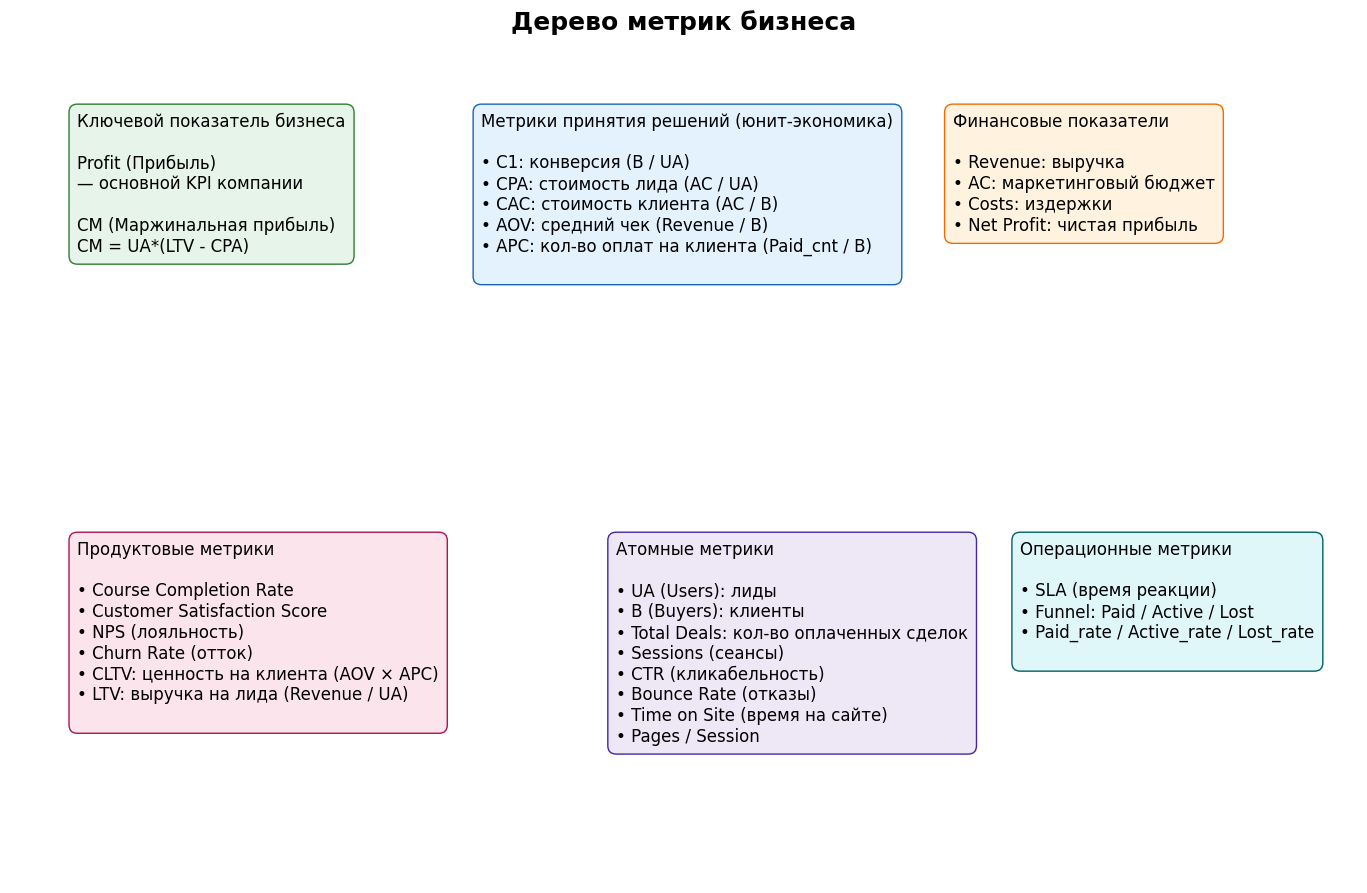

In [20]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 9))
ax.axis("off")

# Заголовок
ax.text(0.5, 1.02, "Дерево метрик бизнеса", ha="center", va="top", fontsize=18, weight="bold")

# Ключевой показатель
ax.text(0.05, 0.9,
        "Ключевой показатель бизнеса\n\n"
        "Profit (Прибыль)\n"
        "— основной KPI компании\n\n"
        "CM (Маржинальная прибыль)\n"
        "CM = UA*(LTV - CPA)",
        ha="left", va="top", fontsize=12,
        bbox=dict(boxstyle="round,pad=0.5", fc="#e6f4ea", ec="#2e7d32"))

# Метрики принятия решений (юнит-экономика)
ax.text(0.35, 0.9,
        "Метрики принятия решений (юнит-экономика)\n\n"
        "• C1: конверсия (B / UA)\n"
        "• CPA: стоимость лида (AC / UA)\n"
        "• CAC: стоимость клиента (AC / B)\n"
        "• AOV: средний чек (Revenue / B)\n"
        "• APC: кол-во оплат на клиента (Paid_cnt / B)\n",
        ha="left", va="top", fontsize=12,
        bbox=dict(boxstyle="round,pad=0.5", fc="#e3f2fd", ec="#1565c0"))

# Финансовые показатели
ax.text(0.7, 0.9,
        "Финансовые показатели\n\n"
        "• Revenue: выручка\n"
        "• AC: маркетинговый бюджет\n"
        "• Costs: издержки\n"
        "• Net Profit: чистая прибыль",
        ha="left", va="top", fontsize=12,
        bbox=dict(boxstyle="round,pad=0.5", fc="#fff3e0", ec="#ef6c00"))

# Продуктовые метрики
ax.text(0.05, 0.4,
        "Продуктовые метрики\n\n"
        "• Course Completion Rate\n"
        "• Customer Satisfaction Score\n"
        "• NPS (лояльность)\n"
        "• Churn Rate (отток)\n"
        "• CLTV: ценность на клиента (AOV × APC)\n"
        "• LTV: выручка на лида (Revenue / UA)\n",
        ha="left", va="top", fontsize=12,
        bbox=dict(boxstyle="round,pad=0.5", fc="#fce4ec", ec="#ad1457"))

# Атомные метрики
ax.text(0.45, 0.4,
        "Атомные метрики\n\n"
        "• UA (Users): лиды\n"
        "• B (Buyers): клиенты\n"
        "• Total Deals: кол-во оплаченных сделок\n"
        "• Sessions (сеансы)\n"
        "• CTR (кликабельность)\n"
        "• Bounce Rate (отказы)\n"
        "• Time on Site (время на сайте)\n"
        "• Pages / Session",
        ha="left", va="top", fontsize=12,
        bbox=dict(boxstyle="round,pad=0.5", fc="#ede7f6", ec="#4527a0"))

# Операционные метрики
ax.text(0.75, 0.4,
        "Операционные метрики\n\n"
        "• SLA (время реакции)\n"
        "• Funnel: Paid / Active / Lost\n"
        "• Paid_rate / Active_rate / Lost_rate\n",
        ha="left", va="top", fontsize=12,
        bbox=dict(boxstyle="round,pad=0.5", fc="#e0f7fa", ec="#006064"))

plt.tight_layout()
plt.show()

### 4. Определить целевые метрики для улучшения продукта и сформулировать гипотезы.

На основе анализа юнит-экономики мною были выделены ключевые показатели, которые напрямую влияют на рост выручки и прибыльность:
- C1 (конверсия UA → B) – доля пользователей, ставших покупателями. Низкая конверсия сигнализирует о потерянных продажах.
- Lost_rate – доля потерянных сделок. Высокий показатель указывает на утечки в воронке продаж.
- CLTV и LTV – ценность клиента и лида. Рост этих метрик повышает выручку на одного пользователя.
- AOV (средний чек) – напрямую влияет на суммарную выручку.
- UA и B – охват и количество платящих пользователей, важны для оценки масштабируемости продукта.
- Active_rate и APC – дополнительные метрики для оценки «теплого» пула клиентов и активности оплат.

Проблемные места и зоны роста:
Анализ по продуктам выявил следующие направления:

**Digital Marketing (Morning)**
- Проблема: C1 крайне низкая (9,8%), Lost_rate высокий (58%), большая база пользователей (UA = 1480)
- Потенциал роста: Повышение конверсии даже на 5–10% приведет к значительному росту выручки

**Web Developer (Morning)**	
- Проблема: C1 = 14,8%, Lost_rate ≈ 48%
- Потенциал роста: Улучшение курса и коммуникаций снизит потерю лидов и повысит Paid_rate

**UX/UI Design (Evening)**	
- Проблема: Небольшая база пользователей (UA = 25), конверсия умеренная (28%)
- Потенциал роста: Расширение охвата и новых каналов маркетинга увеличит UA и суммарную выручку

Программы с Education_Type = Unknown (например, Data Analytics, Find yourself in IT) имеют слишком малые выборки и нерепрезентативны, поэтому их результаты выделены отдельно и не влияют на стратегические решения.

**Гипотезы для улучшения продукта**

**Гипотеза 1: Digital Marketing (Morning) — рост конверсии (C1, Paid_rate)**

- Гипотеза: Сегментирование аудитории по интересам, поведению и демографии, а также персонализированные рекламные кампании (например, таргетированные email-рассылки или рекламные объявления в социальных сетях), увеличат конверсию пользователей в покупателей (C1) на 5–10% за 2 недели.
- Механика улучшения:
Выделить сегменты пользователей с наибольшей вероятностью оплаты.
Запустить таргетированные кампании с персональными офферами;
Отслеживать C1 и Paid_rate по каждому сегменту.
- Целевая метрика:
Paid_rate рост 
C1 рост— конверсия пользователей в покупателей.
Revenue рост — выручка должна расти за счет увеличения числа оплат.
- Критерий успеха: статистически значимый рост C1 минимум на 5%.

**Гипотеза 2: Web Developer (Morning) — снижение оттока (Lost_rate)**

- Гипотеза: Улучшение клиентского пути (автоматические напоминания, контент-сопровождение, доработка курса с упором на практическую ценность) снизит Lost_rate на 10% и увеличит Paid_rate.
- Механика улучшения:
Внедрить email-серию с напоминаниями о незавершённой оплате.
Предложить бонус (чек-лист, демо-урок) для тех, кто “завис” на этапе регистрации.
Провести анализ точек падения воронки и корректировку коммуникаций под конкретные боли пользователей и добавить практические элементы.
- Целевая метрика:
Lost_rate падение — уменьшение числа пользователей, которые не дошли до оплаты.
C1 рост / Paid_rate рост — рост конверсии и доли оплаченных сделок.
- Критерий успеха: снижение Lost_rate минимум на 10%.
  
**Гипотеза 3: UX/UI Design (Morning) — рост конверсии за счёт пакета "портфолио под ключ"**

- Гипотеза: Если предложить новый пакет “портфолио под ключ” (курс + консультации по сборке портфолио + помощь с кейсами), то конверсия Paid_rate вырастет минимум на 5%, а CLTV увеличится.
- Механика:
Разделить трафик на контроль и тестовую группы.
Контрольная группа получает стандартное предложение.
Тестовая группа получает пакет “курс + портфолио под ключ”.
Замерить изменения в Paid_rate и CLTV между группами.
- Целевая метрика:
Paid_rate рост — доля оплаченных сделок должна увеличиться.
CLTV рост — клиенты должны приносить больше ценности за жизненный цикл.
Revenue рост — выручка должна расти за счёт увеличения числа оплат.
- Критерий успеха: рост Paid_rate минимум на 5% и увеличение CLTV без снижения AOV.

### 5. Описать метод проверки гипотез с формулированием условия проведения гипотезы.

#### Гипотеза 1: Digital Marketing (Morning) — рост конверсии (C1, Paid_rate)

**Подробное формулирование гипотезы**
- Контрольная группа: стандартные рекламные кампании без сегментации и персонализации.
- Тестовая группа: рекламные кампании с сегментацией по интересам, поведению и демографии, персонализированные офферы (email, соцсети).
- Гипотеза: персонализированные кампании увеличат Paid_rate на ≥5pp за 2 недели.

**Метрики**
- Основная метрика: Paid_rate = paid_cnt / T.
- Целевая конверсия: рост Paid_rate на 5–10% (например, с 8.73% до ≥13.73%).

**План A/B теста**
- Определение метрики: Paid_rate.
- Разделение аудитории: случайное распределение посетителей на контрольную и тестовую группы.
- Сбор данных: фиксировать количество пользователей и оплат в каждой группе на протяжении 2 недель.
- Проверка гипотезы: Z-тест для двух пропорций, проверка абсолютного прироста ≥5pp.

**Формулирование условий проведения теста**
- Длительность теста: 2 недели.
- Размер выборки: ≥1238 посетителей (T ≥ 2 * 619).
- Порог статистической значимости: 0.05.

#### Механика тестирования

**Подготовка:**
- Сегментировать аудиторию по интересам, поведению и демографии.
- Настроить систему трекинга событий (impression, email_open, click, start_checkout, payment_completed).

**Проведение теста:**
- Случайное распределение пользователей на контрольную и тестовую группы.
- Контрольная группа получает стандартные кампании.
- Тестовая группа получает персонализированные офферы и email-серии.

**Сбор данных:**
- Собирать Paid_cnt и общее число пользователей по группам на протяжении 2 недель.

**Анализ данных:**
- Рассчитать Paid_rate для каждой группы.
- Провести Z-тест, проверить p-value < 0.05 и lift ≥ 0.05.

In [30]:
import numpy as np
from statsmodels.stats.proportion import proportions_ztest

# n1 = число пользователей в контроле, x1 = число оплат в контроле
# n2 = число пользователей в тесте, x2 = число оплат в тесте

n1, x1 = 836, 73    # # примерные данные
n2, x2 = 836, 115  

count = np.array([x1, x2])
nobs = np.array([n1, n2])

stat, pval = proportions_ztest(count, nobs, alternative='two-sided')
p_control = x1 / n1
p_test = x2 / n2
lift_abs = p_test - p_control
lift_rel = (p_test / p_control - 1) if p_control>0 else None

print(f"p_control={p_control:.4f}, p_test={p_test:.4f}")
print(f"abs lift={lift_abs:.4f}, rel lift={lift_rel:.2%}")
print("z-stat:", stat, "p-value:", pval)

# Решение
if (pval < 0.05) and (lift_abs >= 0.05):
    print("Гипотеза подтверждена: статистически значимое увеличение ≥5pp")
else:
    print("Нет подтверждения (либо p>=0.05, либо эффект <5pp)")

p_control=0.0873, p_test=0.1376
abs lift=0.0502, rel lift=57.53%
z-stat: -3.251408612999491 p-value: 0.0011483468643396922
Гипотеза подтверждена: статистически значимое увеличение ≥5pp


**Рекомендации по реализации механики:**

- Сегментировать аудиторию заранее (interest/behavior/demographics).
- Запустить персонализированные офферы + e-mail серии только в тестовой группе.
- Вести лог событий: impression_campaign, email_open, click, start_checkout, payment_completed.
- Pre-check: убедиться, что group распределён случайно и нет смещения по каналам.

#### Гипотеза 2: Web Developer (Morning) — снижение оттока (Lost_rate)

**Подробное формулирование гипотезы**
- Контрольная группа: стандартные коммуникации без автоматических напоминаний.
- Тестовая группа: автоматические напоминания, бонусы и улучшения курса.
- Гипотеза: улучшение клиентского пути снизит Lost_rate минимум на 10% и увеличит Paid_rate.

**Метрики**
- Основная метрика: Lost_rate = lost_cnt / total_users
- Дополнительная метрика: Paid_rate для оценки прироста конверсии

**План A/B теста**
- Определение метрики: Lost_rate.
- Разделение аудитории: случайное распределение пользователей на контрольную и тестовую группы.
- Сбор данных: фиксировать Lost_cnt и общее число пользователей в каждой группе.
- Проверка гипотезы: Z-тест для пропорций; проверка абсолютного снижения ≥10% от исходного Lost_rate.

**Формулирование условий проведения теста**
- Длительность теста: 2 недели или более для накопления достаточного трафика.
- Размер выборки: минимум ~870 пользователей на группу (текущий T=563 недостаточен, можно расширить).
- Порог статистической значимости: 0.05.

#### Механика тестирования

**Подготовка:**
- Настроить серию email-напоминаний и бонусов для тестовой группы.
- Проанализировать точки падения воронки и добавить практические элементы курса.

**Проведение теста:**
- Случайное распределение пользователей на контрольную и тестовую группы.
- Контрольная группа получает стандартное сопровождение.
- Тестовая группа — улучшенный клиентский путь.

**Сбор данных:**
- Зафиксировать Lost_cnt и Paid_cnt на протяжении тестового периода.

**Анализ данных:**
- Рассчитать Lost_rate и Paid_rate.
- Провести Z-тест, проверить p-value < 0.05 и снижение Lost_rate ≥10%.

In [29]:
# x1 = lost_count_control, n1 = total_control
# x2 = lost_count_test, n2 = total_test

n1, x1 = 281, 150   # в реальном тесте вместо примеров будут подставляться данные по контрольной и тестовой группе (n — число пользователей, x — число оплат/потерь
n2, x2 = 282, 120 

count = np.array([x1, x2])
nobs = np.array([n1, n2])

stat, pval = proportions_ztest(count, nobs, alternative='two-sided')
lost_control = x1 / n1
lost_test = x2 / n2
diff = lost_control - lost_test

print(f"lost_control={lost_control:.3f}, lost_test={lost_test:.3f}, abs reduction={diff:.3f}")
print("z:", stat, "p:", pval)
if (pval < 0.05) and (diff >= 0.10 * lost_control):  # требуемое снижение 10% относительно исходного уровня
    print("Гипотеза подтверждена")
else:
    print("Гипотеза не подтверждена или мощности недостаточно")

lost_control=0.534, lost_test=0.426, abs reduction=0.108
z: 2.5712723453476762 p: 0.010132560906106142
Гипотеза подтверждена


**Альтернативные подходы при малом T:**
- Собирать прокси-метрики (email open - click - checkout) и тестировать по ним (меньше выборки нужно).
- Байесовский подход — получить вероятность того, что uplift > 0 (или > MDE) при малых N.

**Рекомендации:**
- Внедрить автоматические напоминания о незавершённой оплате (email-серии или push).
- Предложить бонусы или дополнительные материалы для пользователей, которые «зависли» на этапе регистрации.
- Анализировать точки падения воронки (где пользователи уходят) и корректировать коммуникации под их реальные потребности.
- Разделить пользователей случайным образом на контрольную и тестовую группы, чтобы результат был объективным.

#### Гипотеза 3 — UX/UI Design (Morning) — «портфолио под ключ»
    
**Подробное формулирование гипотезы**
- Контрольная группа: стандартный курс без пакета «портфолио под ключ».
- Тестовая группа: курс + консультации по портфолио и помощь с кейсами.
- Гипотеза: пакет «портфолио под ключ» увеличит Paid_rate минимум на 5% и CLTV.

**Метрики**
- Основная метрика: Paid_rate = paid_cnt / T
- Дополнительная метрика: CLTV (или прокси CLTV_14d)

**План A/B теста**
- Определение метрик: Paid_rate и CLTV
- Разделение аудитории: случайное распределение пользователей на контрольную и тестовую группы (~491 на группу)
- Сбор данных: фиксировать оплаты и CLTV пользователей

**Проверка гипотезы:**
- Paid_rate: Z-тест для пропорций, lift ≥5pp
- CLTV: бутстрэп, доверительный интервал >0 или Pr(diff>0) ≥0.95

**Формулирование условий проведения теста**
- Длительность теста: 2–3 недели для достаточной мощности
- Размер выборки: 491 пользователей на группу
- Порог статистической значимости: 0.05

#### Механика тестирования

**Подготовка:**
- Разделить пользователей на контрольную и тестовую группы.
- Настроить трекинг оплат и CLTV.

**Проведение теста:**
- Контрольная группа получает стандартное предложение.
- Тестовая группа получает пакет «портфолио под ключ».

**Сбор данных:**
- Собирать Paid_cnt и CLTV пользователей каждой группы.

**Анализ данных:**
- Рассчитать Paid_rate и CLTV.
- Z-тест для Paid_rate, бутстрэп для CLTV.

In [25]:
np.random.seed(15)
revenue_control = np.random.exponential(scale=50, size=491)  # примерные данные
revenue_test = np.random.exponential(scale=60, size=491)

def bootstrap_diff(a, b, n_iter=10000):
    diffs = []
    for i in range(n_iter):
        a_s = np.random.choice(a, size=len(a), replace=True)
        b_s = np.random.choice(b, size=len(b), replace=True)
        diffs.append(b_s.mean() - a_s.mean())
    diffs = np.array(diffs)
    return diffs, np.percentile(diffs, [2.5, 97.5]), (diffs > 0).mean()

diffs, ci, prob_positive = bootstrap_diff(revenue_control, revenue_test)
print("mean diff:", diffs.mean(), "95% CI:", ci, "Pr(diff>0)=", prob_positive)

mean diff: 5.106287539228429 95% CI: [-1.36970892 11.65468944] Pr(diff>0)= 0.9383


Критерий успеха для CLTV proxy: доверительный интервал > 0 (или Pr(diff>0) > 0.95).

**Рекомендации:**
- Разделить пользователей на контрольную и тестовую группы случайным образом.
- Контрольная группа получает стандартное предложение курса.
- Тестовая группа получает пакет «портфолио под ключ» (курс + консультации + помощь с кейсами).
- Фиксировать данные по Paid_rate и CLTV, использовать бутстрэп-анализ для оценки эффекта.

## Общий вывод по блоку продуктовой аналитики: 

#### Посчитать юнит-экономику по продуктам
В рамках анализа юнит-экономики определены наиболее перспективные направления (Digital Marketing и UX/UI Design) и продукты, требующие улучшений (Web Developer, Digital Marketing Morning). Также выявлены нерепрезентативные данные, которые требуют корректировки процессов сбора и верификации.
Рекомендации: сосредоточиться на масштабировании сильных продуктов, оптимизации маркетинга и пути клиента в слабых сегментах, а также наладить корректный трекинг данных.

#### Из юнит-экономики определить точки роста бизнеса
Выявлены ключевые зоны роста через повышение конверсии и удержания. Продукты с высокой ценностью клиента, но низкой конверсией, требуют доработки в коммуникации и сегментации.
Рекомендации: тестировать улучшения воронки, усиливать маркетинг в сегментах с высоким CLTV и расширять охват наиболее рентабельных направлений.

#### Понять дерево метрик для бизнеса
Построено дерево метрик, отражающее связь между ключевыми показателями (охват, конверсия, удержание, CLTV). Это позволило выделить приоритетные узкие места для воздействия.
Рекомендации: использовать дерево метрик как основу для приоритизации гипотез и контроля результативности изменений.

#### Понять на какую метрику продукта они будут воздействовать и сформировать гипотезы
Сформированы гипотезы, направленные на улучшение Paid Rate, конверсии в оплату и CLTV. Подобраны конкретные сценарии для разных продуктов (e-mail напоминания, персонализированные офферы, «портфолио под ключ» и др.).
Рекомендации: фокусироваться на гипотезах с быстрым циклом проверки (до 2 недель) и высокой ожидаемой ценностью.

#### Описать метод проверки гипотез
Для каждой гипотезы описан план тестирования: разбиение на тестовую и контрольную группы, фиксация метрик (Paid_rate, CLTV, конверсии), сбор событий и статистическая оценка эффекта.
Рекомендации: строго соблюдать рандомизацию и методологию A/B-тестов, применять бутстрэп-анализ и фиксировать бизнес-метрики для исключения искажений.

## Заключение
В результате проведённого анализа были рассчитаны ключевые показатели юнит-экономики, что позволило выделить наиболее сильные продукты (Digital Marketing, UX/UI Design) и зоны, требующие доработки (Web Developer, Digital Marketing Morning). Также обнаружены нерепрезентативные данные, что указывает на необходимость пересмотра процессов сбора и верификации информации.

Определены точки роста бизнеса через повышение конверсии и удержания, а также масштабирование направлений с высокой ценностью клиента. Построенное дерево метрик дало целостное представление о взаимосвязях показателей и позволило выделить узкие места, требующие приоритетного внимания.

Сформированы гипотезы, ориентированные на улучшение Paid Rate, CLTV и конверсии в оплату, с акцентом на быстрые и практичные сценарии тестирования. Для их проверки предложена методология A/B-тестов с обязательным контролем рандомизации и фиксацией бизнес-метрик, что обеспечивает объективность результатов и исключает статистические искажения.

#### Итоговые рекомендации:
- Масштабировать успешные продукты и усиливать маркетинг в сегментах с высоким CLT.
- Оптимизировать путь клиента и коммуникации для продуктов с низкой конверсией.
- Внедрить системный контроль качества данных.
- Использовать дерево метрик как основу для постоянного мониторинга и приоритизации гипотез.
- Проверять гипотезы в коротком цикле, применяя строгую методологию A/B-тестирования.